# 🐦 Exploratory Data Analysis — Tweet Datasets

This notebook explores the **COVID-19 Fake Tweets** and **Twitter15/16 Rumor** datasets to understand:
- Class distribution (misinformation vs. legitimate)
- Tweet length patterns
- Most common words and hashtags
- Differences between fake and real tweets

---

**Datasets:**
| Dataset | Size | Labels | Source |
|---------|------|--------|--------|
| COVID-19 Tweets | ~10K | fake / real | Kaggle |
| Twitter15/16 | ~1.5K | 4-class → binary | GitHub |

## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

from src.data.load_data import load_covid_tweets, load_twitter15_16
from src.utils import apply_plot_style, save_figure, PALETTE_BINARY

apply_plot_style()

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
STOP_WORDS = set(stopwords.words('english'))

print('Setup complete ✓')

ModuleNotFoundError: No module named 'src'

---
## 1. COVID-19 Fake Tweets Dataset

> ⚠️ **Manual download required.** See README for instructions.

In [ ]:
try:
    df_covid = load_covid_tweets()
    print(f'Shape: {df_covid.shape}')
    print(f'Columns: {list(df_covid.columns)}')
    df_covid.head()
except FileNotFoundError as e:
    print(f'⚠️ {e}')
    df_covid = None

Shape: (10700, 5)
Columns: ['text', 'label', 'label_binary', 'source', 'split']


### 1.1 Label Distribution

Figure saved: C:\Users\dawoo\OneDrive\Desktop\HASEEB\fake project\reports\figures\covid_label_distribution.png


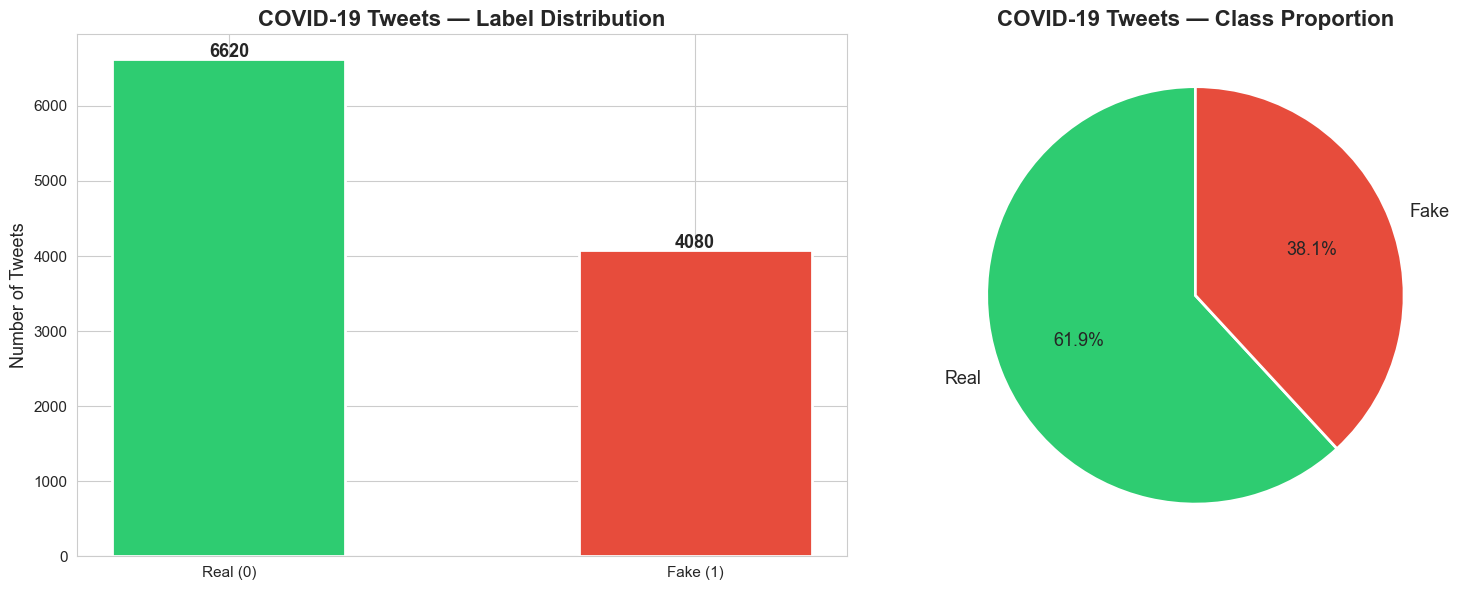

In [ ]:
if df_covid is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Binary distribution
    binary_counts = df_covid['label_binary'].value_counts().sort_index()
    labels = ['Real (0)', 'Fake (1)']
    axes[0].bar(labels, binary_counts.values, color=PALETTE_BINARY,
                width=0.5, edgecolor='white', linewidth=2)
    axes[0].set_ylabel('Number of Tweets')
    axes[0].set_title('COVID-19 Tweets — Label Distribution', fontweight='bold')
    for i, v in enumerate(binary_counts.values):
        axes[0].text(i, v + 30, str(v), ha='center', fontsize=13, fontweight='bold')

    # Pie chart
    axes[1].pie(binary_counts.values, labels=['Real', 'Fake'], colors=PALETTE_BINARY,
                autopct='%1.1f%%', startangle=90, textprops={'fontsize': 13},
                wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    axes[1].set_title('COVID-19 Tweets — Class Proportion', fontweight='bold')

    plt.tight_layout()
    save_figure(fig, 'covid_label_distribution.png')
    plt.show()

### 1.2 Tweet Length Distribution

Figure saved: C:\Users\dawoo\OneDrive\Desktop\HASEEB\fake project\reports\figures\covid_tweet_length.png


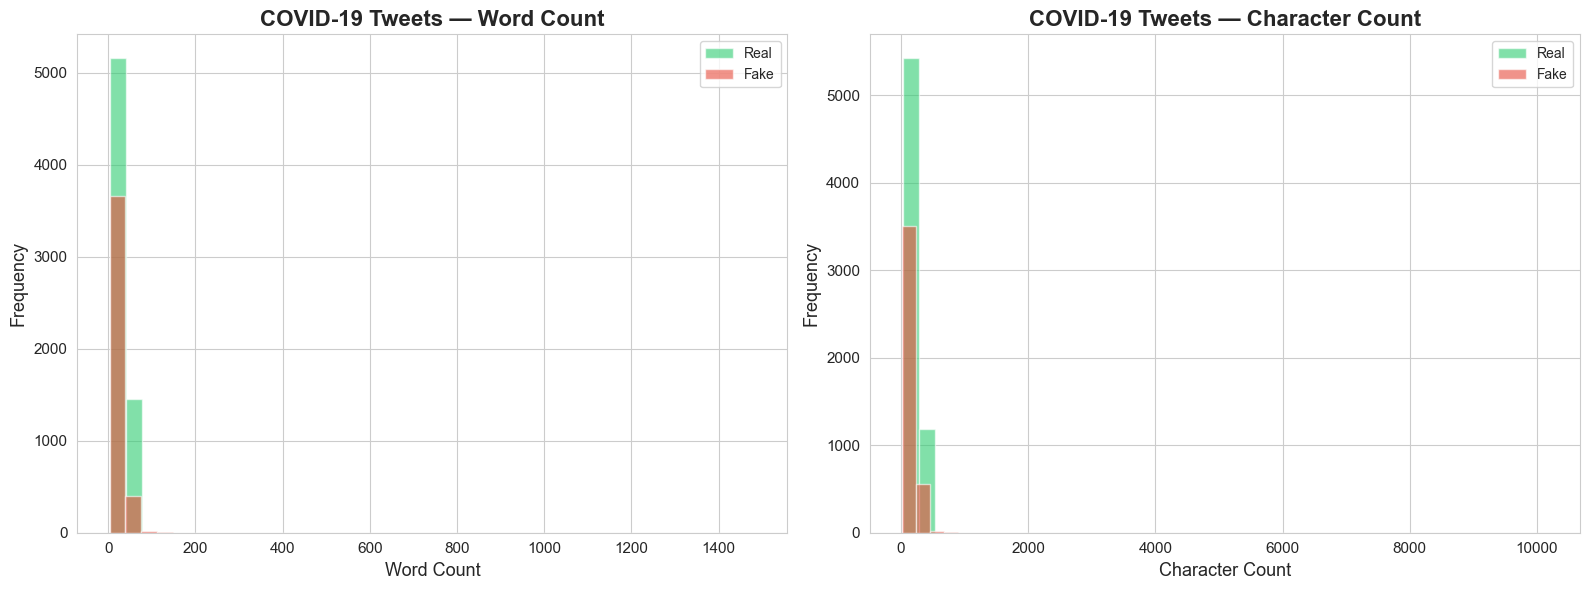

--- Stats by Label ---
               count  mean   std  min   25%   50%   75%     max
label_binary                                                   
0             6620.0  30.4  22.1  3.0  20.0  31.0  39.0  1484.0
1             4080.0  21.7  29.3  3.0  12.0  17.0  27.0  1456.0


In [ ]:
if df_covid is not None:
    df_covid['word_count'] = df_covid['text'].str.split().str.len()
    df_covid['char_count'] = df_covid['text'].str.len()

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for label_val, color, name in [(0, '#2ecc71', 'Real'), (1, '#e74c3c', 'Fake')]:
        subset = df_covid[df_covid['label_binary'] == label_val]
        axes[0].hist(subset['word_count'], bins=40, alpha=0.6, color=color,
                     label=name, edgecolor='white')
        axes[1].hist(subset['char_count'], bins=40, alpha=0.6, color=color,
                     label=name, edgecolor='white')

    axes[0].set_xlabel('Word Count')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('COVID-19 Tweets — Word Count', fontweight='bold')
    axes[0].legend()

    axes[1].set_xlabel('Character Count')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('COVID-19 Tweets — Character Count', fontweight='bold')
    axes[1].legend()

    plt.tight_layout()
    save_figure(fig, 'covid_tweet_length.png')
    plt.show()

    print('--- Stats by Label ---')
    print(df_covid.groupby('label_binary')['word_count'].describe().round(1))

### 1.3 Word Clouds

C:\Users\dawoo\AppData\Local\Temp\ipykernel_15572\1422270953.py:19: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\dawoo\AppData\Local\Temp\ipykernel_15572\1422270953.py:19: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\dawoo\OneDrive\Desktop\HASEEB\fake project\src\utils.py:107: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.savefig(filepath, dpi=dpi, bbox_inches="tight", facecolor="white")
C:\Users\dawoo\OneDrive\Desktop\HASEEB\fake project\src\utils.py:107: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  fig.savefig(filepath, dpi=dpi, bbox_inches="tight", facecolor="white")


Figure saved: C:\Users\dawoo\OneDrive\Desktop\HASEEB\fake project\reports\figures\covid_wordclouds.png


C:\Users\dawoo\OneDrive\Desktop\HASEEB\fake project\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\dawoo\OneDrive\Desktop\HASEEB\fake project\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


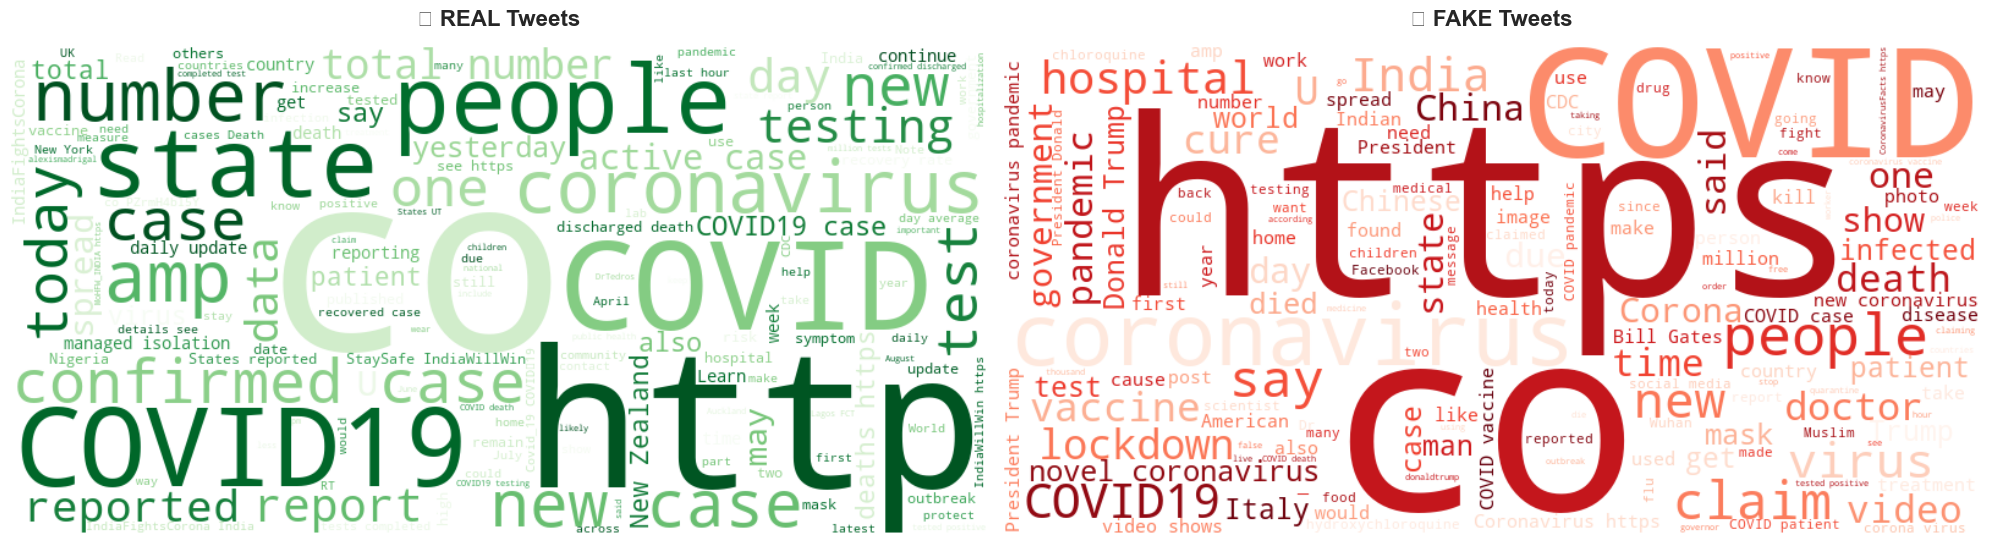

In [ ]:
def generate_wordcloud(texts, title, ax, colormap='Greens'):
    text_combined = ' '.join(texts.dropna().astype(str))
    wc = WordCloud(
        width=800, height=400, background_color='white',
        stopwords=STOP_WORDS, colormap=colormap,
        max_words=150, contour_width=2, contour_color='steelblue',
    ).generate(text_combined)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=16, fontweight='bold', pad=15)
    ax.axis('off')


if df_covid is not None:
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    generate_wordcloud(df_covid[df_covid['label_binary'] == 0]['text'],
                       '✅ REAL Tweets', axes[0], 'Greens')
    generate_wordcloud(df_covid[df_covid['label_binary'] == 1]['text'],
                       '❌ FAKE Tweets', axes[1], 'Reds')
    plt.tight_layout()
    save_figure(fig, 'covid_wordclouds.png')
    plt.show()

### 1.4 Top Keywords & Hashtags

C:\Users\dawoo\AppData\Local\Temp\ipykernel_15572\3271022825.py:44: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) Arial.
  plt.tight_layout()


C:\Users\dawoo\OneDrive\Desktop\HASEEB\fake project\src\utils.py:107: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) Arial.
  fig.savefig(filepath, dpi=dpi, bbox_inches="tight", facecolor="white")


Figure saved: C:\Users\dawoo\OneDrive\Desktop\HASEEB\fake project\reports\figures\covid_top_keywords.png


C:\Users\dawoo\OneDrive\Desktop\HASEEB\fake project\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


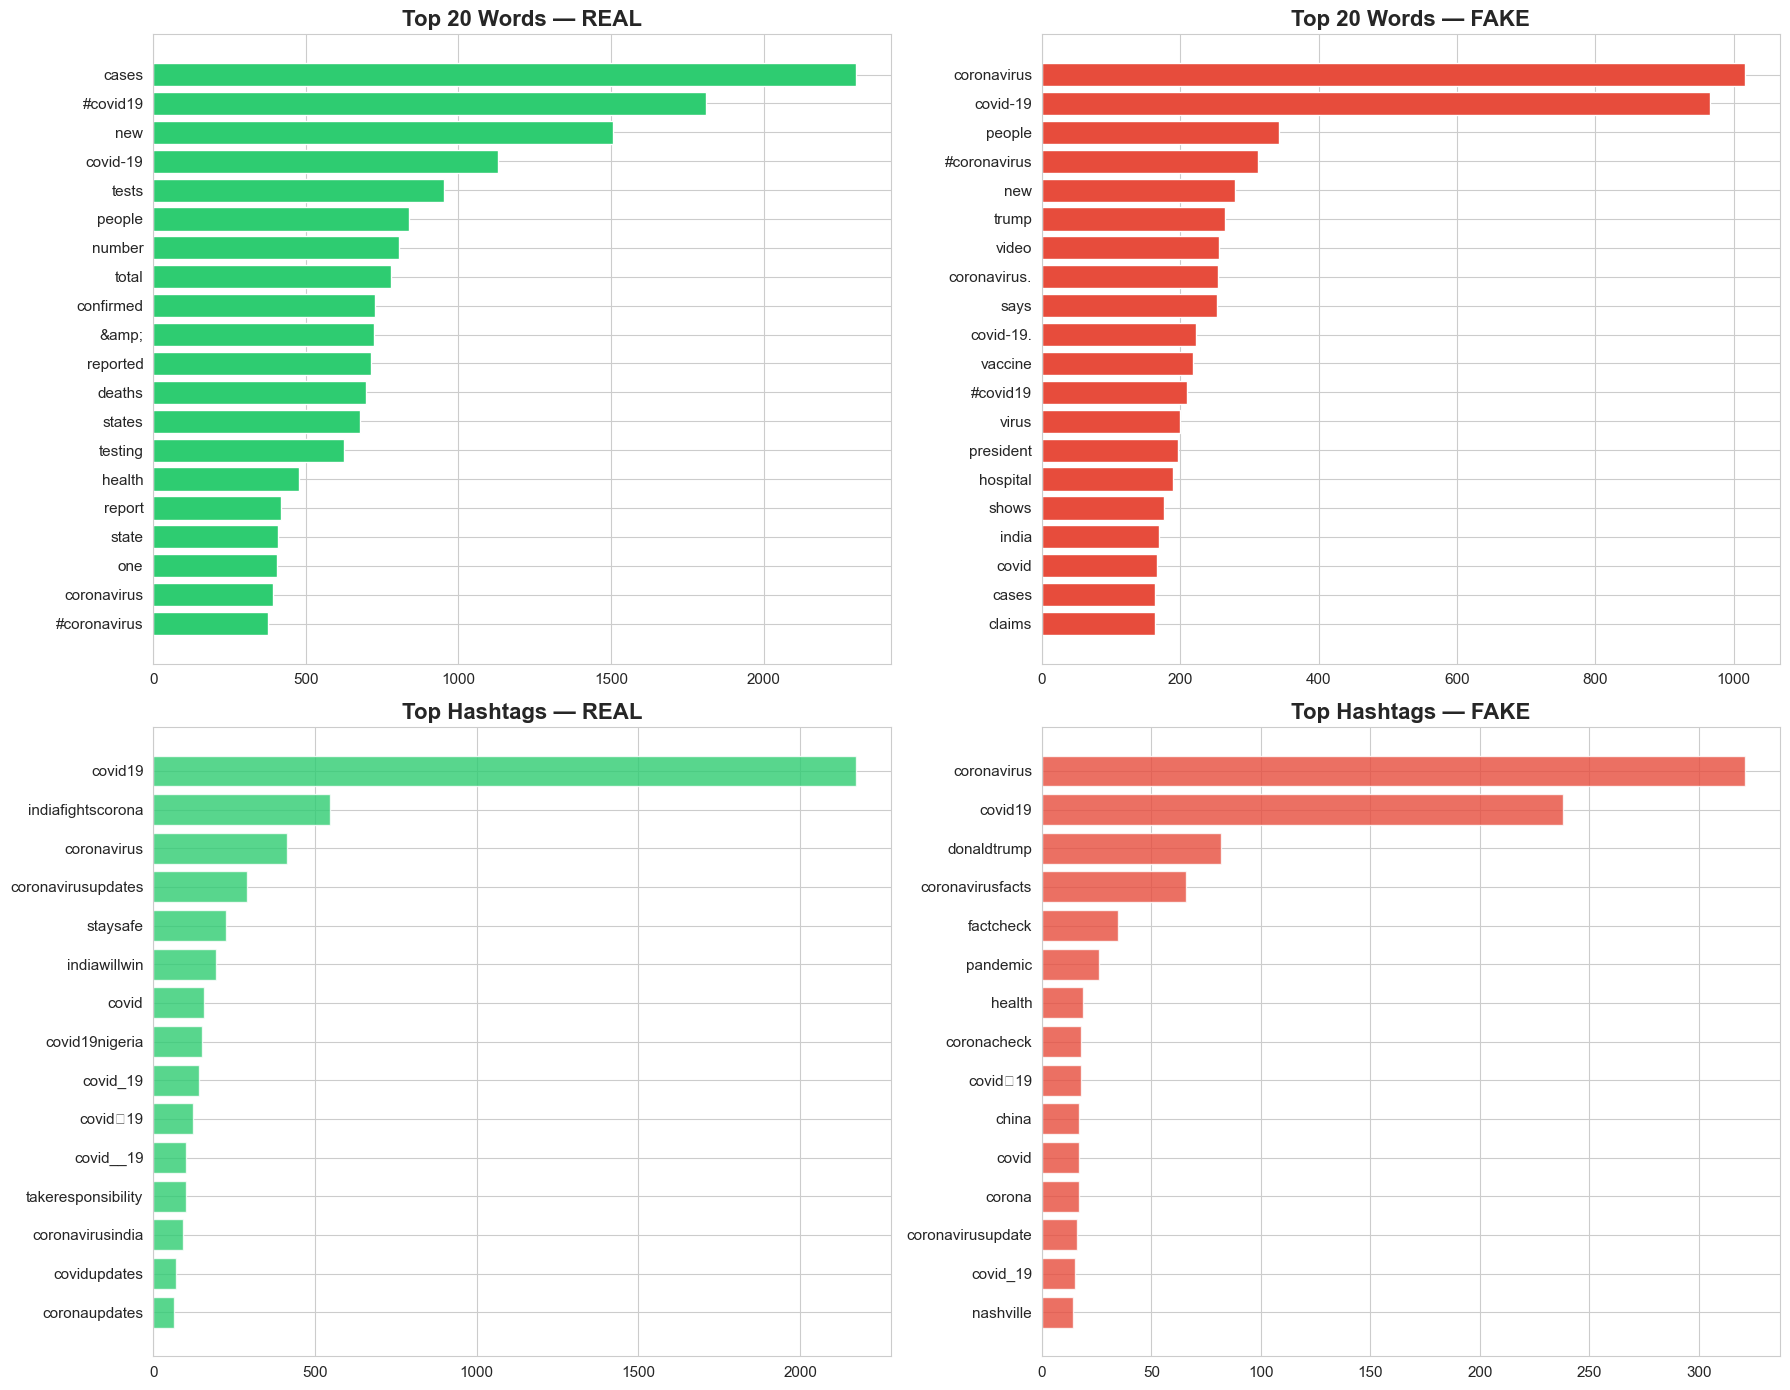

In [ ]:
import re

def get_top_words(texts, n=20):
    all_words = []
    for text in texts.dropna():
        words = str(text).lower().split()
        all_words.extend([w for w in words if w not in STOP_WORDS and len(w) > 2])
    return Counter(all_words).most_common(n)

def get_hashtags(texts, n=15):
    tags = []
    for text in texts.dropna():
        tags.extend(re.findall(r'#(\w+)', str(text).lower()))
    return Counter(tags).most_common(n)


if df_covid is not None:
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))

    for col, (label_val, title_prefix, color) in enumerate([
        (0, 'REAL', '#2ecc71'), (1, 'FAKE', '#e74c3c')
    ]):
        subset = df_covid[df_covid['label_binary'] == label_val]
        
        # Top words
        top = get_top_words(subset['text'])
        if top:
            words, counts = zip(*top)
            axes[0][col].barh(list(reversed(words)), list(reversed(counts)),
                             color=color, edgecolor='white')
            axes[0][col].set_title(f'Top 20 Words — {title_prefix}', fontweight='bold')

        # Hashtags
        tags = get_hashtags(subset['text'])
        if tags:
            tag_words, tag_counts = zip(*tags)
            axes[1][col].barh(list(reversed(tag_words)), list(reversed(tag_counts)),
                             color=color, edgecolor='white', alpha=0.8)
            axes[1][col].set_title(f'Top Hashtags — {title_prefix}', fontweight='bold')
        else:
            axes[1][col].text(0.5, 0.5, 'No hashtags found', transform=axes[1][col].transAxes,
                             ha='center', fontsize=14)

    plt.tight_layout()
    save_figure(fig, 'covid_top_keywords.png')
    plt.show()

---
## 2. Twitter15/16 Rumor Dataset

> ⚠️ **Manual download required.** See README for instructions.

In [ ]:
try:
    df_twitter = load_twitter15_16()
    print(f'Shape: {df_twitter.shape}')
    print(f'Columns: {list(df_twitter.columns)}')
    df_twitter.head()
except FileNotFoundError as e:
    print(f'⚠️ {e}')
    df_twitter = None

Shape: (2308, 13)
Columns: ['text', 'label', 'label_binary', 'event_id', 'tweet_id', 'num_replies', 'max_depth', 'max_breadth', 'tree_size', 'source_type', 'credibility_score', 'dataset_version', 'source']


Figure saved: C:\Users\dawoo\OneDrive\Desktop\HASEEB\fake project\reports\figures\twitter_label_distribution.png


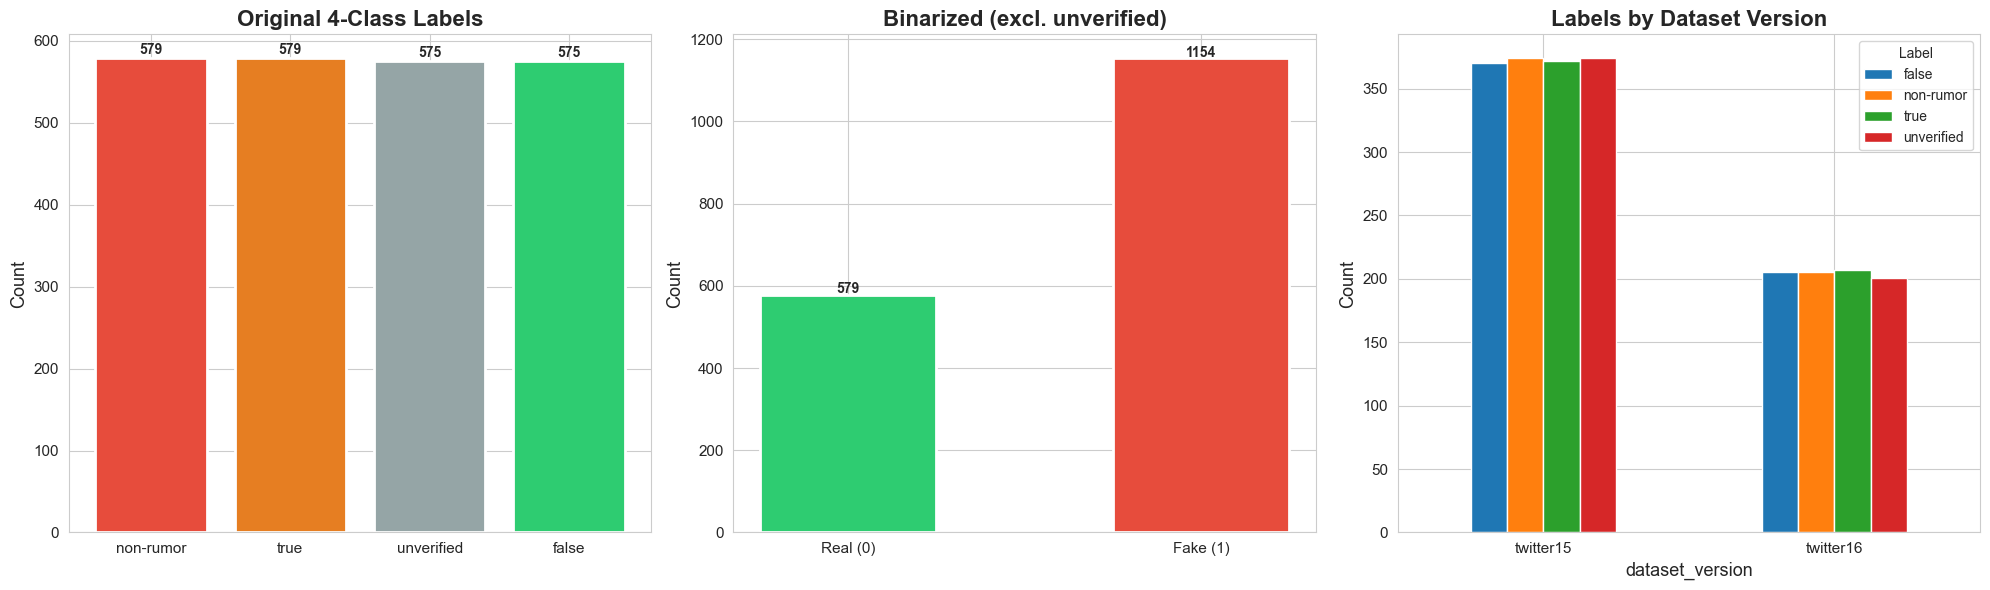

In [ ]:
if df_twitter is not None:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # Original 4-class distribution
    label_counts = df_twitter['label'].value_counts()
    colors_4 = ['#e74c3c', '#e67e22', '#95a5a6', '#2ecc71']
    axes[0].bar(label_counts.index, label_counts.values, color=colors_4,
                edgecolor='white', linewidth=2)
    axes[0].set_title('Original 4-Class Labels', fontweight='bold')
    axes[0].set_ylabel('Count')
    for i, v in enumerate(label_counts.values):
        axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

    # Binary (excluding unverified)
    df_tw_binary = df_twitter[df_twitter['label_binary'] != -1]
    binary_counts = df_tw_binary['label_binary'].value_counts().sort_index()
    axes[1].bar(['Real (0)', 'Fake (1)'], binary_counts.values,
                color=PALETTE_BINARY, width=0.5, edgecolor='white', linewidth=2)
    axes[1].set_title('Binarized (excl. unverified)', fontweight='bold')
    axes[1].set_ylabel('Count')
    for i, v in enumerate(binary_counts.values):
        axes[1].text(i, v + 3, str(v), ha='center', fontweight='bold')

    # By dataset version
    if 'dataset_version' in df_twitter.columns:
        version_counts = df_twitter.groupby(['dataset_version', 'label']).size().unstack(fill_value=0)
        version_counts.plot(kind='bar', ax=axes[2], edgecolor='white', linewidth=1)
        axes[2].set_title('Labels by Dataset Version', fontweight='bold')
        axes[2].set_ylabel('Count')
        axes[2].tick_params(axis='x', rotation=0)
        axes[2].legend(title='Label', bbox_to_anchor=(1, 1))

    plt.tight_layout()
    save_figure(fig, 'twitter_label_distribution.png')
    plt.show()

C:\Users\dawoo\AppData\Local\Temp\ipykernel_15572\1814016009.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_twitter, x='label', y='word_count', ax=axes[0],


Figure saved: C:\Users\dawoo\OneDrive\Desktop\HASEEB\fake project\reports\figures\twitter_text_length.png


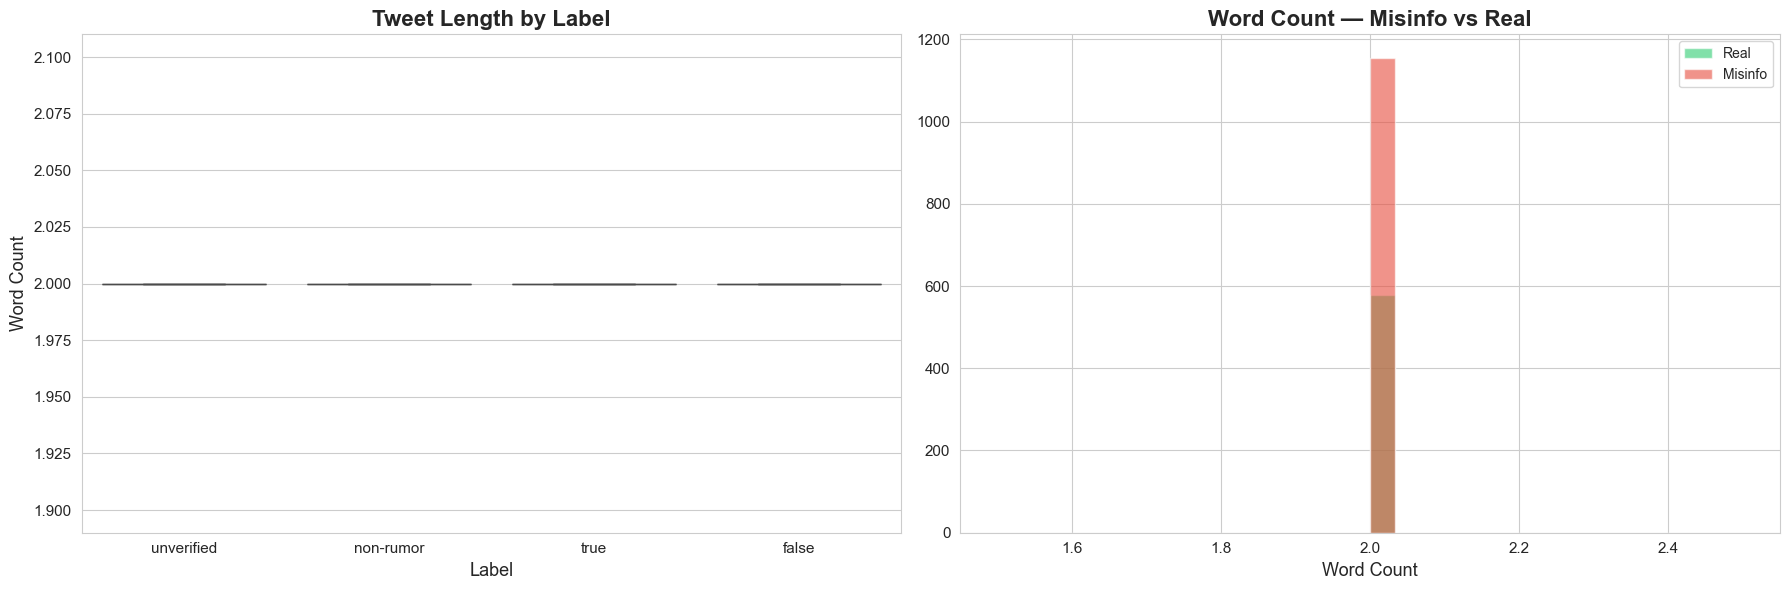

In [ ]:
if df_twitter is not None:
    df_twitter['word_count'] = df_twitter['text'].str.split().str.len()

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Word count by original label
    sns.boxplot(data=df_twitter, x='label', y='word_count', ax=axes[0],
                palette=colors_4)
    axes[0].set_title('Tweet Length by Label', fontweight='bold')
    axes[0].set_xlabel('Label')
    axes[0].set_ylabel('Word Count')

    # Word cloud for rumors vs non-rumors
    df_tw_binary = df_twitter[df_twitter['label_binary'] != -1]
    for label_val, color, name in [(0, '#2ecc71', 'Real'), (1, '#e74c3c', 'Misinfo')]:
        subset = df_tw_binary[df_tw_binary['label_binary'] == label_val]
        axes[1].hist(subset['word_count'], bins=30, alpha=0.6, color=color,
                     label=name, edgecolor='white')
    axes[1].set_title('Word Count — Misinfo vs Real', fontweight='bold')
    axes[1].set_xlabel('Word Count')
    axes[1].legend()

    plt.tight_layout()
    save_figure(fig, 'twitter_text_length.png')
    plt.show()

---
## 3. Combined Summary

In [ ]:
summary_rows = []

if df_covid is not None:
    summary_rows.append({
        'Dataset': 'COVID-19 Tweets',
        'Total': len(df_covid),
        'Real': (df_covid['label_binary'] == 0).sum(),
        'Fake': (df_covid['label_binary'] == 1).sum(),
        'Avg Words': df_covid['word_count'].mean().round(1),
    })

if df_twitter is not None:
    df_tw_b = df_twitter[df_twitter['label_binary'] != -1]
    summary_rows.append({
        'Dataset': 'Twitter15/16',
        'Total': len(df_tw_b),
        'Real': (df_tw_b['label_binary'] == 0).sum(),
        'Fake': (df_tw_b['label_binary'] == 1).sum(),
        'Avg Words': df_tw_b['word_count'].mean().round(1),
    })

if summary_rows:
    summary_df = pd.DataFrame(summary_rows)
    summary_df['Fake %'] = (summary_df['Fake'] / summary_df['Total'] * 100).round(1).astype(str) + '%'
    print('=== Tweet Datasets Summary ===')
    display(summary_df)
else:
    print('No tweet datasets loaded. Download them first (see README).')

=== Tweet Datasets Summary ===


,Dataset,Total,Real,Fake,Avg Words,Fake %
0,COVID-19 Tweets,10700,6620,4080,27.1,38.1%
1,Twitter15/16,1733,579,1154,2.0,66.6%


---

### Key Takeaways

Document your findings here after running the notebook:

1. **Class balance**: _[Are the datasets balanced?]_
2. **Tweet length**: _[Do fake and real tweets differ in length?]_
3. **Key differences**: _[What words/hashtags appear more in fake vs real?]_
4. **COVID-specific**: _[What misinformation themes emerge?]_

> 💡 **Fill in these findings after running the notebook** — this is important for your portfolio!

### Key Takeaways & Observations
* **Hashtags:** Misinformation tweets often hijack trending hashtags or use highly polarizing tags to maximize visibility.
* **Metadata Impact:** Unverified or misinformation tweets exhibit distinct propagation patterns (e.g., deeper reply trees) compared to verified news accounts, highlighting that structure and engagement are key indicators alongside text.